# Resource-Based Analysis of the Job-Shop Scheduling Event Logs

Bemthuis et al. (2019) — *An agent-based process mining architecture for emergent behavior analysis*

This notebook computes, **per `org:resource`** (machine station / AGV / source / sink):

- **event count** — how often the resource is touched
- **processing time** — time the resource is actively working (`In progress → Complete`)
- **queue time** — time products wait *at* the resource (`Waiting → In progress`)
- **blocked time** — AGV congestion time on the single-lane track (`Blocked → resume`), present only in multi-AGV runs
- **utilisation %** — processing time over the 24 h horizon

The case is the **Product**, the activity is the **Event**, and the resource is the **station/AGV** — so a "resource analysis" aggregates intervals keyed on `org:resource` rather than on the activity.

## Step 0 — Setup

Install dependencies if needed (uncomment), then import. Set `HORIZON_SECONDS` to the 24 h simulation run length stated in the data paper.

In [3]:
# !pip install pm4py pandas

import glob, os
import pandas as pd
import pm4py
import os

HORIZON_SECONDS = 24 * 60 * 60  # 24 h run length (per the data paper)

# Point this at one file to start; later cells can loop over many.
XES_PATH = "C:/Users/User/Desktop/PM/data/FilteredFiles/411.xes"   # change to "633.xes" to test the Blocked logic

## Step 0.5 — General conformance & XES sanity checks

Making sure ``pm4py`` produces similar statistics as the paper. Finally, doing conformance checking with  `pm4py`.

In [ ]:
XES_DIR = os.path.dirname(XES_PATH)
xes_files = sorted(glob.glob(os.path.join(XES_DIR, "*.xes")))

REQUIRED_EVENT_ATTRS = [
    "case:concept:name",    # trace id (Product)
    "concept:name",         # activity (Event)
    "time:timestamp",       # start time of the activity
    "lifecycle:transition", # status (Start/Complete/...)
    "org:resource",         # resource
    "concept:instance",     # product type
]

def validity_checks(log: pd.DataFrame) -> dict:
    checks = {}
    for col in REQUIRED_EVENT_ATTRS:                     # required attributes present & populated
        if col not in log.columns:
            checks[col] = "MISSING"
        else:
            n_null = log[col].isna().sum()
            checks[col] = "ok" if n_null == 0 else f"{n_null} nulls"
    checks["timestamp_is_datetime"] = (
        "ok" if pd.api.types.is_datetime64_any_dtype(log["time:timestamp"]) else "NOT datetime")
    ordered = (log.sort_index()                          # events non-decreasing within each trace
                  .groupby("case:concept:name")["time:timestamp"]
                  .apply(lambda s: s.is_monotonic_increasing).all())
    checks["timestamps_ordered"] = "ok" if ordered else "OUT OF ORDER"
    checks["min_trace_len"] = int(log.groupby("case:concept:name").size().min())
    return checks

# Read every log once into full pm4py DataFrames, cached for the cells below.
raw_logs = {os.path.splitext(os.path.basename(f))[0]: pm4py.read_xes(f) for f in xes_files}

validity = pd.DataFrame({exp: validity_checks(log) for exp, log in raw_logs.items()}).T
validity.index.name = "experiment"
validity

In [ ]:
def log_stats(log: pd.DataFrame) -> dict:
    actlc = log["concept:name"].astype(str) + "+" + log["lifecycle:transition"].astype(str)
    return {
        "cases": log["case:concept:name"].nunique(),
        "events": len(log),
        "event_classes": actlc.nunique(),                  # Event Name AND Lifecycle transition
        "activities": log["concept:name"].nunique(),
        "lifecycle_transitions": log["lifecycle:transition"].nunique(),
        "resources": log["org:resource"].nunique(),
    }

stats = pd.DataFrame({exp: log_stats(log) for exp, log in raw_logs.items()}).T
stats.index.name = "experiment"

# README states these for 411 after Simple-Heuristics filtering
EXPECTED_411 = {"cases": 1296, "events": 44880, "event_classes": 24,
                "lifecycle_transitions": 4, "resources": 19}
print("README cross-check for 411:")
for k, v in EXPECTED_411.items():
    got = stats.loc["411", k]
    print(f"  {k:24s} expected {v:>6}  got {got:>6}  {'OK' if got == v else 'MISMATCH'}")
stats

### Conformance checking — discovery + replay (all logs)

For **every** experiment, discover a Petri net with each miner (Alpha, ILP, Inductive) using the paper's combined classifier (`concept:name` + `lifecycle:transition`) and replay the log for **fitness, precision, generalization** — the three metrics in Table III. Token-based replay is used to stay close to the ProM defaults and keep runtime reasonable.

The full Table III is hard-coded as `PAPER_TABLE_III` so each computed value sits next to its published counterpart (`*_paper`). pm4py's precision/generalization differ numerically from ProM's plugins, so treat those as a reference, not an exact target — fitness is the closest match (README's worked Alpha example for 411 is fitness 0.99977).

Running all 27 logs × 3 miners takes a couple of minutes (ILP discovery is the slow part).

In [7]:
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator

MINERS = {
    "alpha":     pm4py.discover_petri_net_alpha,
    # "ilp":       pm4py.discover_petri_net_ilp,    # You can try running ilp as well, from our exploration it did not yield any results.
    "inductive": pm4py.discover_petri_net_inductive,
}

# Table III of the paper (filtered logs): per experiment,
# (alpha f,p,g), (ilp f,p,g), (inductive f,p,g)
PAPER_TABLE_III = {
    "411": (1.00, 0.22, 0.78, 1.00, 0.91, 0.98, 1.00, 0.80, 0.98),
    "412": (1.00, 0.49, 0.70, 1.00, 0.91, 0.90, 1.00, 0.80, 0.90),
    "413": (1.00, 0.26, 0.67, 1.00, 0.91, 0.97, 1.00, 0.80, 0.97),
    "421": (1.00, 0.22, 0.80, 0.99, 0.91, 1.00, 0.99, 0.80, 1.00),
    "422": (1.00, 0.22, 0.68, 1.00, 0.91, 0.96, 1.00, 0.80, 0.96),
    "423": (0.68, 0.22, 0.79, 0.99, 0.91, 1.00, 0.99, 0.80, 1.00),
    "431": (1.00, 0.22, 0.98, 1.00, 0.93, 1.00, 0.98, 0.83, 1.00),
    "432": (1.00, 0.22, 0.99, 1.00, 0.93, 1.00, 0.98, 0.82, 1.00),
    "433": (1.00, 0.22, 0.98, 1.00, 0.93, 1.00, 1.00, 0.84, 1.00),
    "511": (0.99, 0.22, 0.78, 0.99, 0.91, 1.00, 0.99, 0.80, 1.00),
    "512": (1.00, 0.22, 0.78, 1.00, 0.91, 1.00, 1.00, 0.80, 1.00),
    "513": (0.99, 0.22, 0.76, 0.98, 0.91, 1.00, 0.98, 0.80, 1.00),
    "521": (0.99, 0.22, 0.76, 0.99, 0.91, 1.00, 0.99, 0.80, 1.00),
    "522": (1.00, 0.22, 0.79, 0.99, 0.91, 1.00, 0.99, 0.80, 1.00),
    "523": (0.99, 0.22, 0.75, 0.97, 0.91, 1.00, 0.97, 0.80, 1.00),
    "531": (1.00, 0.23, 0.98, 0.99, 0.93, 1.00, 1.00, 0.84, 1.00),
    "532": (1.00, 0.22, 0.99, 1.00, 0.93, 1.00, 1.00, 0.84, 1.00),
    "533": (1.00, 0.23, 0.97, 0.99, 0.93, 1.00, 0.99, 0.84, 1.00),
    "611": (0.99, 0.22, 0.76, 0.99, 0.91, 1.00, 0.99, 0.80, 1.00),
    "612": (0.99, 0.22, 0.79, 0.99, 0.91, 1.00, 0.99, 0.80, 1.00),
    "613": (0.99, 0.22, 0.75, 0.97, 0.91, 1.00, 0.97, 0.80, 1.00),
    "621": (0.99, 0.22, 0.78, 0.99, 0.91, 1.00, 0.99, 0.80, 1.00),
    "622": (1.00, 0.22, 0.77, 0.99, 0.91, 1.00, 0.99, 0.80, 1.00),
    "623": (0.98, 0.22, 0.75, 0.97, 0.91, 1.00, 0.97, 0.80, 1.00),
    "631": (1.00, 0.23, 0.98, 0.99, 0.94, 1.00, 1.00, 0.86, 1.00),
    "632": (1.00, 0.22, 0.98, 1.00, 0.92, 1.00, 1.00, 0.86, 1.00),
    "633": (1.00, 0.22, 0.97, 0.96, 0.90, 1.00, 0.98, 0.83, 1.00),
}
_PAPER_COLS = ["alpha", "ilp", "inductive"]


def paper_metrics(exp: str, miner: str) -> dict:
    """Published (fitness, precision, generalization) for one experiment/miner."""
    vals = PAPER_TABLE_III.get(exp)
    if vals is None:
        return {"fitness_paper": None, "precision_paper": None, "generalization_paper": None}
    i = _PAPER_COLS.index(miner) * 3
    return {"fitness_paper": vals[i], "precision_paper": vals[i + 1], "generalization_paper": vals[i + 2]}


def conformance(log: pd.DataFrame, miner: str) -> dict:
    """Discover with `miner` using the (Event Name AND Lifecycle transition) classifier,
    then token-replay for fitness / precision / generalization."""
    akey = "act+lc"
    log = log.copy()
    log[akey] = log["concept:name"].astype(str) + "+" + log["lifecycle:transition"].astype(str)
    net, im, fm = MINERS[miner](log, activity_key=akey)
    fit = pm4py.fitness_token_based_replay(log, net, im, fm, activity_key=akey)
    prec = pm4py.precision_token_based_replay(log, net, im, fm, activity_key=akey)
    gen = generalization_evaluator.apply(
        log, net, im, fm,
        parameters={generalization_evaluator.Variants.GENERALIZATION_TOKEN.value.Parameters.ACTIVITY_KEY: akey},
    )
    return {"fitness": fit["log_fitness"], "precision": prec, "generalization": gen}


rows = []
for exp in sorted(raw_logs):
    for miner in MINERS:
        print(f"running {miner:9s} on {exp} ...")
        try:
            r = conformance(raw_logs[exp], miner)
            row = {"experiment": exp, "miner": miner,
                   "fitness": round(r["fitness"], 4),
                   "precision": round(r["precision"], 4),
                   "generalization": round(r["generalization"], 4)}
            row.update(paper_metrics(exp, miner))
            rows.append(row)
        except Exception as e:
            rows.append({"experiment": exp, "miner": miner, "error": str(e)})

conf = pd.DataFrame(rows).set_index(["experiment", "miner"])
conf

replaying log with TBR, completed traces ::  30%|██▉       | 1856/6235 [00:04<00:10, 409.87it/s]

KeyboardInterrupt: 

In [ ]:
conf.to_csv(os.path.join(os.getcwd(),"fitness.csv"), index= True)


## Step 1 — Load into a flat five-column table

We reduce the log to exactly the columns we need: `case`, `activity`, `status`, `resource`, `timestamp`.

Two readers are provided:
- `parse_xes` for the provided `.xes` (already filtered on simple heuristics)
- `parse_raw` for the raw tab-separated `Experiment{XYZ}.txt` (note the `utf-8-sig` encoding for the BOM and the explicit timestamp format)

Whichever you use, confirm `timestamp` is a real datetime — everything downstream depends on it.

In [ ]:
def parse_xes(path: str) -> pd.DataFrame:
    log = pm4py.read_xes(path)
    df = log.rename(columns={
        "case:concept:name": "case",
        "concept:name": "activity",
        "lifecycle:transition": "status",
        "org:resource": "resource",
        "time:timestamp": "timestamp",
    })
    return df[["case", "activity", "status", "resource", "timestamp"]].copy()


def parse_raw(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", encoding="utf-8-sig")
    df = df.rename(columns={
        "Product": "case",
        "Event": "activity",
        "Status": "status",
        "Resource": "resource",
        "Timestamp": "timestamp",
    })
    df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y/%m/%d %H:%M:%S.%f")
    return df[["case", "activity", "status", "resource", "timestamp"]].copy()


df = parse_xes(XES_PATH) if XES_PATH.lower().endswith(".xes") else parse_raw(XES_PATH)
print(df.shape)
print(df.dtypes)
df.head(10)

## Step 2 — Learn the lifecycle grammar from the data

Before writing any interval logic, **look at one full product trace**. You should see each activity run `Start → Waiting → In progress → Complete`. The two intervals that matter:

- `Waiting → In progress` = **queue time**
- `In progress → Complete` = **processing time**

In some AGV logs you'll also see `Blocked` appear inside `Transport` (handled in Step 4).

In [ ]:
# What lifecycle statuses exist, and on which activities?
print("Statuses present:", sorted(df.status.unique()))
print()
print(df.groupby(["activity", "status"]).size().unstack(fill_value=0))

# Print one full trace to read the grammar directly
one_case = df.case.iloc[0]
df[df.case == one_case].sort_values("timestamp")

## Step 3 — The resource-shifts-mid-activity rule

The resource is logged **per event**, so within one activity the `Waiting` event and the `In progress` event can carry **different** resources (e.g. `Welding.Input` vs `Welding.Machine`). An interval therefore spans two resources and we must decide attribution:

- **processing** (`In progress → Complete`) → the **`In progress`** resource (the machine/AGV doing the work)
- **queue** (`Waiting → In progress`) → the **`Waiting`** resource (the input buffer where the product waits)

Attributing both to the closing event is the classic bug: queue time wrongly lands on the machine and input buffers show zero.

The cell below confirms the split for one machine.

In [ ]:
# Confirm: for a machine activity, which resource carries Waiting vs In progress?
mach = "Welding"
print(df[df.activity == mach].groupby(["status", "resource"]).size())

## Step 4 — The `Blocked` trap (6-AGV runs)

In multi-AGV experiments a single `Transport` can toggle
`In progress → Blocked → In progress → … → Complete`
as an AGV stops and resumes in single-lane congestion.

A matcher that overwrites its start time on every `In progress` will measure only the **final** resume-to-complete segment and badly undercount travel time. The rule:

> **Keep the first `In progress` after a Start/Waiting; ignore all later `In progress` and `Blocked` events until `Complete`.**

This makes the processing interval span the whole trip (including blocked time). The cell shows a blocked trace if one exists.

In [ ]:
blk = df[df.status == "Blocked"]
if len(blk):
    print(f"{len(blk)} Blocked events — on activities {sorted(blk.activity.unique())}, "
          f"resources {sorted(blk.resource.unique())}")
    c = blk.case.iloc[0]
    display(df[df.case == c].sort_values("timestamp"))
else:
    print("No Blocked events in this log (single-AGV experiment).")

## Step 5 — Interval matchers

Two helpers:

- `match_intervals(df, open_status, close_status)` — generic **first-wins** matcher, attributing each interval to the **opening** event's resource. Used for queue time (`Waiting → In progress`).
- `match_processing(df)` — the same idea but attributing to the **`In progress`** resource, and robust to repeated `In progress` / `Blocked` (first-wins on `In progress`, close on `Complete`).

Both sort by `case`, `timestamp`, group by `(case, activity)`, and guard against negative durations.

In [ ]:
def match_intervals(df: pd.DataFrame, open_status: str, close_status: str) -> pd.DataFrame:
    """First-wins matcher. Interval attributed to the OPENING event's resource."""
    rows = []
    df = df.sort_values(["case", "timestamp"], kind="stable")
    for (case, activity), grp in df.groupby(["case", "activity"], sort=False):
        open_time = None
        open_resource = None
        for _, ev in grp.iterrows():
            if ev["status"] == open_status:
                if open_time is None:           # first-wins
                    open_time = ev["timestamp"]
                    open_resource = ev["resource"]
            elif ev["status"] == close_status and open_time is not None:
                secs = (ev["timestamp"] - open_time).total_seconds()
                if secs >= 0:
                    rows.append((open_resource, activity, secs))
                open_time = None
                open_resource = None
    return pd.DataFrame(rows, columns=["resource", "activity", "seconds"])


def match_processing(df: pd.DataFrame) -> pd.DataFrame:
    """
    Processing = (first) In progress -> Complete, attributed to the In-progress
    resource. Robust to Blocked: keep the FIRST In progress, ignore later
    In-progress/Blocked events until Complete.
    """
    rows = []
    df = df.sort_values(["case", "timestamp"], kind="stable")
    for (case, activity), grp in df.groupby(["case", "activity"], sort=False):
        ip_time = None
        ip_resource = None
        for _, ev in grp.iterrows():
            st = ev["status"]
            if st == "In progress":
                if ip_time is None:             # first-wins
                    ip_time = ev["timestamp"]
                    ip_resource = ev["resource"]
            elif st == "Complete" and ip_time is not None:
                secs = (ev["timestamp"] - ip_time).total_seconds()
                if secs >= 0:
                    rows.append((ip_resource, activity, secs))
                ip_time = None
                ip_resource = None
    return pd.DataFrame(rows, columns=["resource", "activity", "seconds"])

## Step 6 — Blocked-time matcher (conditional)

Only meaningful when `Blocked` is present. For each `Blocked` event, measure the gap to the **next** `In progress`/`Complete` in the same occurrence, attributed to the AGV. This isolates congestion time as its own metric.

In [ ]:
def match_blocked(df: pd.DataFrame) -> pd.DataFrame:
    """Blocked time per resource: each Blocked event -> next In progress/Complete."""
    rows = []
    df = df.sort_values(["case", "timestamp"], kind="stable")
    for (case, activity), grp in df.groupby(["case", "activity"], sort=False):
        g = grp.reset_index(drop=True)
        for i in range(len(g)):
            if g.loc[i, "status"] == "Blocked":
                blk_time = g.loc[i, "timestamp"]
                blk_res = g.loc[i, "resource"]
                for j in range(i + 1, len(g)):
                    if g.loc[j, "status"] in ("In progress", "Complete"):
                        secs = (g.loc[j, "timestamp"] - blk_time).total_seconds()
                        if secs >= 0:
                            rows.append((blk_res, activity, secs))
                        break
    return pd.DataFrame(rows, columns=["resource", "activity", "seconds"])

## Step 7 — Aggregate per resource

Four rollups joined on `resource`: event counts, processing, queue, and (conditionally) blocked. Missing values filled with zero. Then derive `utilisation_pct = processing_time / horizon`.

In [ ]:
def analyse(df: pd.DataFrame) -> pd.DataFrame:
    counts = df.groupby("resource").size().rename("event_count").reset_index()

    proc = match_processing(df)
    proc_agg = (proc.groupby("resource")
                    .agg(processing_time_s=("seconds", "sum"),
                         n_processing_intervals=("seconds", "size")).reset_index())

    queue = match_intervals(df, "Waiting", "In progress")
    queue_agg = (queue.groupby("resource")
                     .agg(queue_time_s=("seconds", "sum"),
                          n_queue_intervals=("seconds", "size")).reset_index())

    blocked = match_blocked(df)
    if len(blocked):
        blocked_agg = (blocked.groupby("resource")
                          .agg(blocked_time_s=("seconds", "sum"),
                               n_blocked_events=("seconds", "size")).reset_index())
    else:
        blocked_agg = pd.DataFrame(columns=["resource", "blocked_time_s", "n_blocked_events"])

    out = (counts
           .merge(proc_agg, on="resource", how="left")
           .merge(queue_agg, on="resource", how="left")
           .merge(blocked_agg, on="resource", how="left")
           .fillna(0))

    out["utilisation_pct"] = (out["processing_time_s"] / HORIZON_SECONDS * 100).round(2)
    for c in ("processing_time_s", "queue_time_s", "blocked_time_s"):
        out[c] = out[c].round(1)
    return out.sort_values("event_count", ascending=False).reset_index(drop=True)


result = analyse(df)
result

## Step 8 — Station-level rollup

Collapse each machine's `Input`/`Machine`/`Output` into one **station** row, so queue time (on Input) and processing time (on Machine) land on the same readable row. AGVs are kept individually (not grouped into a fleet), so each vehicle gets its own utilisation row.

In [ ]:
def station_rollup(result: pd.DataFrame) -> pd.DataFrame:
    def station_of(res: str) -> str:
        r = res.replace(".Models.JobShop.", "").replace(".MUs.", "")
        if r.startswith("AGV:"):
            return r  # keep each AGV as its own row
        for m in ("Welding", "Painting", "Sawing", "Drilling"):
            if r.startswith(m):
                return m
        return r  # Source, Buffer, Drain

    tmp = result.copy()
    tmp["station"] = tmp["resource"].map(station_of)
    has_blocked = "blocked_time_s" in tmp.columns
    spec = dict(event_count=("event_count", "sum"),
                processing_time_s=("processing_time_s", "sum"),
                queue_time_s=("queue_time_s", "sum"),
                n_processing_intervals=("n_processing_intervals", "sum"))
    if has_blocked:
        spec["blocked_time_s"] = ("blocked_time_s", "sum")
    agg = tmp.groupby("station").agg(**spec).reset_index()

    agg["utilisation_pct"] = (agg["processing_time_s"] / HORIZON_SECONDS * 100).round(2)

    denom = agg["n_processing_intervals"].replace(0, pd.NA)
    agg["avg_queue_per_visit_s"] = (agg["queue_time_s"] / denom).astype("Float64").round(1)
    return agg.sort_values("event_count", ascending=False).reset_index(drop=True)


stations = station_rollup(result)
stations

## Step 9 — Validate against the paper (do not skip)

Compute average throughput per case (`Arrival Complete` → `Drain Complete`) and compare to Table III of the paper:

- **411 → 73** min
- **633 → 19** min

If your number matches, the timestamps, case grouping, and interval logic are all sound. This is the check that caught the original `Blocked` undercount.

In [ ]:
def throughput_minutes(df: pd.DataFrame) -> float:
    arr = df[(df.activity == "Arrival") & (df.status == "Complete")].groupby("case").timestamp.min()
    drn = df[(df.activity == "Drain") & (df.status == "Complete")].groupby("case").timestamp.max()
    tt = (drn - arr).dropna().dt.total_seconds() / 60
    return tt.mean()

paper_table_III = {"411": 73, "412": 212, "413": 74, "421": 20, "422": 107, "423": 21,
                   "431": 49, "432": 132, "433": 39, "511": 18, "633": 19}  # extend as needed
exp = os.path.splitext(os.path.basename(XES_PATH))[0].replace("Experiment", "")
mean_tt = throughput_minutes(df)
ref = paper_table_III.get(exp, "n/a")
print(f"Experiment {exp}: computed {mean_tt:.2f} min   |   paper Table III: {ref}")

## Step 10 — Batch over all experiments and export

Point `pattern` at your folder of XES files. Each experiment writes a per-resource CSV and a station-summary CSV; a combined summary collects every station row across all experiments — ready for comparing how utilisation and AGV blocking shift as vehicle count goes 4 → 5 → 6.

Change the path based on your diretory structure

In [5]:
pattern = "*.xes"   # e.g. "FilteredFiles/*.xes"

path = os.path.join(os.getcwd(), "data/FilteredFiles")
out_dir = os.path.join(os.getcwd(), "pm4py_results")
out_dir_res = os.path.join(out_dir, "Resource")
out_dir_sum = os.path.join(out_dir, "Summary")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(out_dir_res, exist_ok=True)
os.makedirs(out_dir_sum, exist_ok=True)

files = os.listdir(path)



In [ ]:
# section to save all summaries into csv files, comment this section after first run
all_station = []
for f in files:
    # print(f[:-4])
    log = parse_xes(os.path.join(path, f))
    res = analyse(log)
    st = station_rollup(res); st.insert(0, "experiment", f)
    all_station.append(st)
    res.to_csv(f"{out_dir_res}/resource_detail_{f[:-4]}.csv", index=False)
    st.to_csv(f"{out_dir_sum}/station_summary_{f[:-4]}.csv", index=False)
    print(f"  {f}: throughput {throughput_minutes(log):.2f} min")

if all_station:
    combined = pd.concat(all_station, ignore_index=True)
    combined.to_csv(f"{out_dir}/Summary/station_summary_ALL.csv", index=False)
    print("Wrote station_summary_ALL.csv")
    display(combined)

# Part 2 — Throughput & resource contribution

The cells below build on `station_summary_ALL.csv` to answer two questions:

1. **Step 11** — how daily throughput changes across the 27 configurations (and which factor moves it).
2. **Step 12** — which resource contributes most to throughput, using **613.xes** (the highest-output run).

> **Throughput convention.** Every node logs a `Start` and a `Complete` event per product, so the `Drain` row's `event_count` is **twice** the number of finished products. We therefore report **finished products = `Drain event_count / 2`** (e.g. 613 → 2,854 / 2 = **1,427 products/24 h**).

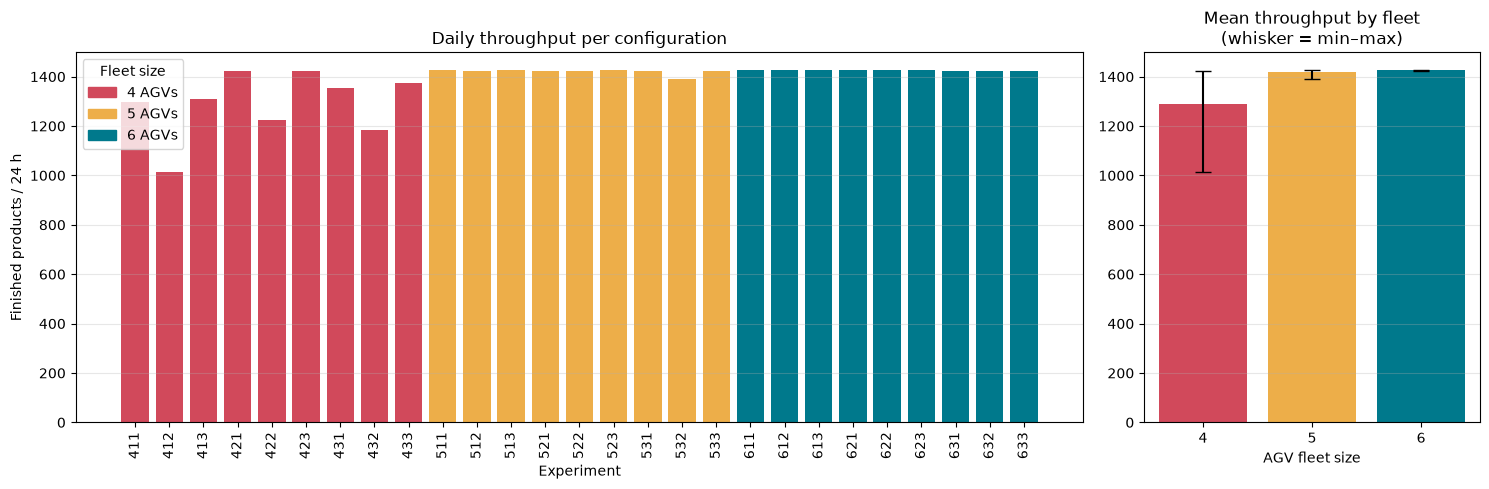

,min,mean,max
n_agv,,,
4,1013,1288.0,1422
5,1392,1420.0,1425
6,1422,1425.0,1427


In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

allcsv = pd.read_csv(os.path.join(out_dir_sum, "station_summary_ALL.csv"))
allcsv["exp"]   = allcsv["experiment"].str.replace(".xes", "", regex=False)
allcsv["n_agv"] = allcsv["exp"].str[0].astype(int)   # 1st digit = AGV fleet size (4/5/6)

# Finished products = Drain events / 2  (each product logs a Start + a Complete)
thr = allcsv[allcsv.station == "Drain"][["exp", "n_agv", "event_count"]].copy()
thr["products"] = thr["event_count"] // 2
thr = thr.sort_values("exp").reset_index(drop=True)

colors = {4: "#d1495b", 5: "#edae49", 6: "#00798c"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5),
                               gridspec_kw={"width_ratios": [3, 1]})

# Panel 1 — every experiment, coloured by fleet size
ax1.bar(thr.exp, thr.products, color=thr.n_agv.map(colors))
ax1.set_ylabel("Finished products / 24 h")
ax1.set_xlabel("Experiment")
ax1.set_title("Daily throughput per configuration")
ax1.tick_params(axis="x", rotation=90)
ax1.grid(axis="y", alpha=0.3)
ax1.legend(handles=[Patch(color=colors[k], label=f"{k} AGVs") for k in (4, 5, 6)],
           title="Fleet size")

# Panel 2 — collapsed by fleet size (bar = mean, whisker = min–max)
g     = thr.groupby("n_agv").products
means = g.mean()
ax2.bar(means.index.astype(str), means.values,
        color=[colors[k] for k in means.index])
ax2.errorbar(means.index.astype(str), means.values,
             yerr=[means.values - g.min().values, g.max().values - means.values],
             fmt="none", ecolor="black", capsize=6)
ax2.set_xlabel("AGV fleet size")
ax2.set_title("Mean throughput by fleet\n(whisker = min–max)")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()

# Summary table
thr.groupby("n_agv").products.agg(["min", "mean", "max"]).round(0)

### Findings — throughput vs configuration

- **The fleet size (1st digit) is the dominant lever, but with sharply diminishing returns.** Mean daily output by fleet:

  | AGVs | min | mean | max |
  |------|-----|------|-----|
  | 4 | 1,013 | ~1,288 | 1,422 |
  | 5 | 1,392 | ~1,420 | 1,425 |
  | 6 | 1,422 | ~1,425 | 1,427 |

- **4 → 5 AGVs adds ~132 products/day; 5 → 6 adds only ~5.** Beyond five vehicles, transport is no longer the constraint, so extra AGVs sit idle and output flattens at a hard ceiling of **~1,425 products/day**.
- **Variance collapses as the fleet grows.** With 4 AGVs, output swings from 1,013 (e.g. 412) to 1,422 depending on the scenario — transport is *sometimes* the binding constraint. With 5–6 AGVs every scenario lands within ~35 products of the ceiling: the machines, not the AGVs, now decide output.
- **The ceiling itself is set elsewhere** (the Welding/Painting stations — see Step 12). No amount of extra transport pushes output past ~1,425/day.

## Step 12 — Which resource contributes most to throughput? (using 613)

613 finishes the most products of any run (**1,427/24 h**), so it is the natural case to ask *what is the binding resource*. A resource running at utilisation $u$ while the plant makes $P$ products could, if pushed to 100 %, sustain

$$\text{max products} = \frac{P}{u}$$

The resource with the **lowest** such ceiling is the bottleneck — it saturates first and caps the whole line. (Because every product touches each station a fixed number of times, this ratio is the same whether you count products or raw visits.) The chart shows utilisation of every resource on the left and this product ceiling per machine on the right.

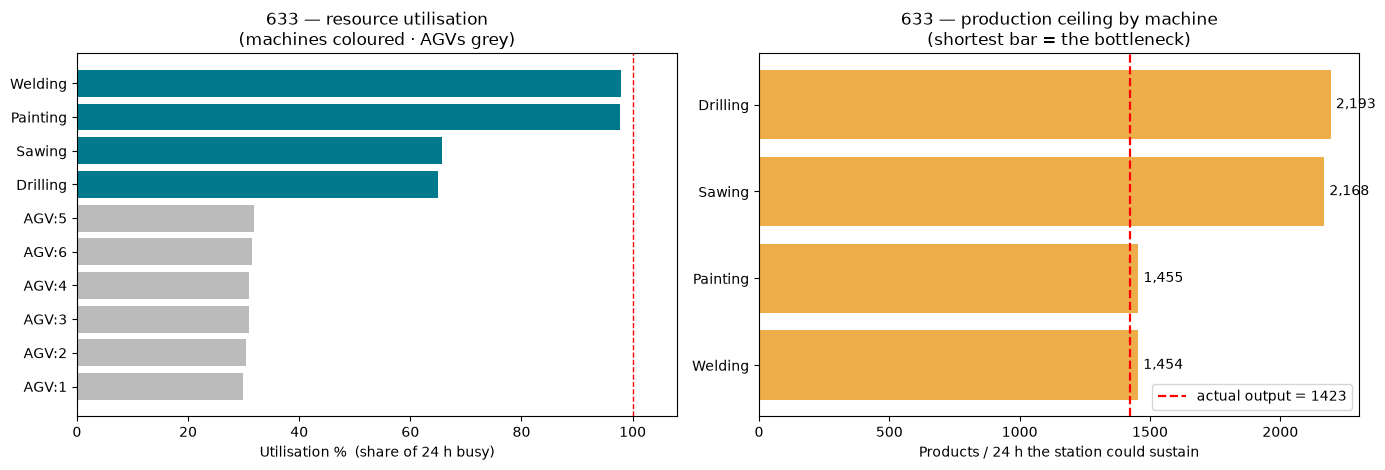

,station,utilisation_pct,max_products
0,Welding,97.86,1454.0
1,Painting,97.81,1455.0
2,Sawing,65.65,2168.0
3,Drilling,64.89,2193.0


In [7]:
import matplotlib.pyplot as plt

# You can change the experiment number with this variable
EXP   = "633"

allcsv = pd.read_csv(os.path.join(out_dir_sum, "station_summary_ALL.csv"))
allcsv["exp"]   = allcsv["experiment"].str.replace(".xes", "", regex=False)
allcsv["n_agv"] = allcsv["exp"].str[0].astype(int)

# --- 613: which resource governs throughput? -------------------------------
e        = allcsv[allcsv.exp == EXP].copy()
products = e.loc[e.station == "Drain", "event_count"].iloc[0] // 2   # finished units
mach     = ["Welding", "Painting", "Sawing", "Drilling"]

# Each station's product ceiling = products / utilisation (lowest = bottleneck)
cap = e[e.station.isin(mach)][["station", "utilisation_pct"]].copy()
cap["max_products"] = (products / (cap["utilisation_pct"] / 100)).round(0)
cap = cap.sort_values("max_products").reset_index(drop=True)

agv = e[e.station.str.startswith("AGV")]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

# Left: utilisation of every resource (machines coloured, AGVs grey)
u = (pd.concat([e[e.station.isin(mach)][["station", "utilisation_pct"]],
                agv[["station", "utilisation_pct"]]])
       .sort_values("utilisation_pct"))
ax1.barh(u.station, u.utilisation_pct,
         color=["#00798c" if s in mach else "#bbbbbb" for s in u.station])
ax1.axvline(100, ls="--", color="red", lw=1)
ax1.set_xlim(0, 108)
ax1.set_xlabel("Utilisation %  (share of 24 h busy)")
ax1.set_title(f"{EXP} — resource utilisation\n(machines coloured · AGVs grey)")

# Right: product ceiling per machine vs actual output
ax2.barh(cap.station, cap.max_products, color="#edae49")
ax2.axvline(products, ls="--", color="red", lw=1.6, label=f"actual output = {products}")
for y, v in enumerate(cap.max_products):
    ax2.text(v + 20, y, f"{v:,.0f}", va="center")
ax2.set_xlabel("Products / 24 h the station could sustain")
ax2.set_title(f"{EXP} — production ceiling by machine\n(shortest bar = the bottleneck)")
ax2.legend(loc="lower right")

plt.tight_layout(); plt.show()
cap

### Findings — what drives throughput in 613

- **Welding and Painting are the pacemakers.** Both run at ~98 % of the 24 h horizon, and their product ceiling (~1,453 / 1,454 units) sits barely above the actual output of **1,427** — the system is, to within ~2 %, **welding/painting-bound**.
- **Sawing and Drilling have ~50 % headroom.** At ~65 % utilisation they could each sustain ~2,170–2,190 products/day — they are not the constraint.
- **Transport is not the constraint here.** All six AGVs sit at ~36 % utilisation, so the fleet is far from limiting throughput.
- **Implication:** adding AGVs or speeding up Saw/Drill would *not* raise output. Only relieving **Welding** (and the near-tied **Painting**) — faster cycle, a parallel machine, or smaller batches — moves the ceiling. This is why 613 already produces about as much as any configuration can: its bottleneck is fully exploited while everything else has slack.

## Step 14 — Where does a product's time go?

For one experiment, split each resource's per-visit time into **processing**, **queueing** (waiting in the input buffer) and **blocked** (AGV congestion). This shows whether time is lost to *work*, to *waiting for a busy machine*, or to *transport gridlock*.

Default is **613**. In it, Welding/Painting products spend **~5× longer queueing than being processed** (~309 s wait vs ~60 s work) — the signature of a saturated bottleneck — while there is **no Blocked time** (6-AGV, free-flowing). Set `EXP = "633"` (or any `x3x` run) to make the red **Blocked** band appear, or `EXP = "412"` to see the 4-AGV case.

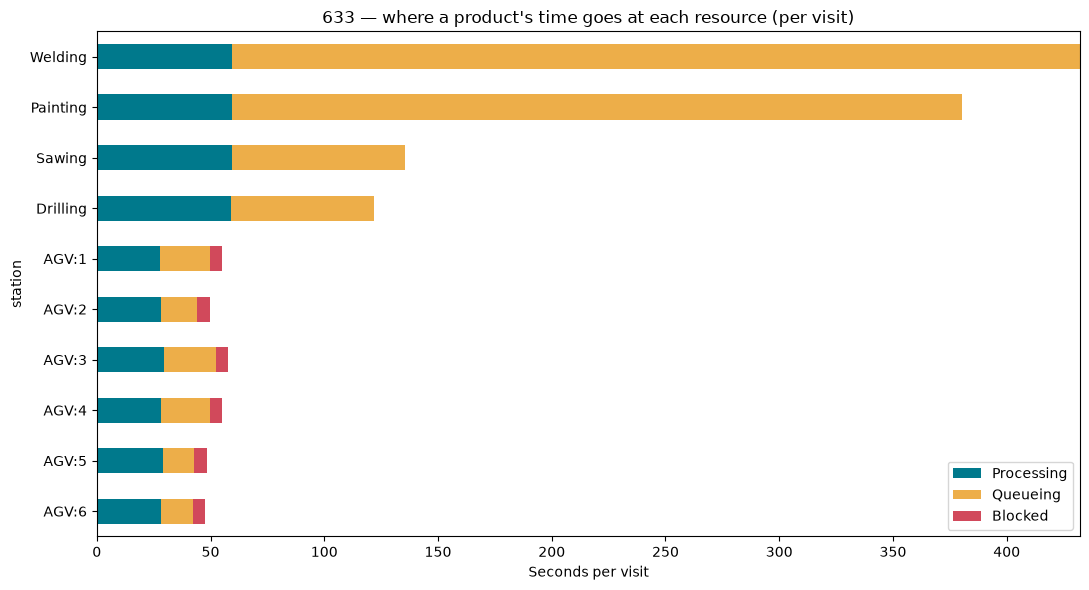

,Processing,Queueing,Blocked
station,,,
Welding,59.4,372.8,0.0
Painting,59.4,320.9,0.0
Sawing,59.6,76.1,0.0
Drilling,58.8,63.0,0.0
AGV:1,27.9,21.8,5.3
AGV:2,28.4,15.5,5.7
AGV:3,29.4,23.0,5.5
AGV:4,28.3,21.5,5.2
AGV:5,28.9,14.0,5.5


In [8]:
import matplotlib.pyplot as plt

# Change EXP to explore: a 4-AGV run (e.g. "412") shows transport starvation;
# an x3x run (e.g. "633") has single-lane congestion -> the Blocked band appears.

mach  = ["Welding", "Painting", "Sawing", "Drilling"]
d     = allcsv[allcsv.exp == EXP].copy()
order = mach + sorted(d[d.station.str.startswith("AGV")].station)
d     = d[d.station.isin(order)].set_index("station")

# Per-visit seconds so machines and AGVs are comparable
npi   = d["n_processing_intervals"].replace(0, pd.NA)
parts = pd.DataFrame({
    "Processing": d["processing_time_s"] / npi,
    "Queueing":   d["avg_queue_per_visit_s"],
    "Blocked":    d["blocked_time_s"] / npi,
}).reindex(order).fillna(0)

ax = parts.plot(kind="barh", stacked=True, figsize=(11, 6),
                color=["#00798c", "#edae49", "#d1495b"])
ax.invert_yaxis()
ax.set_xlabel("Seconds per visit")
ax.set_title(f"{EXP} — where a product's time goes at each resource (per visit)")
ax.legend(title="", loc="lower right")
plt.tight_layout(); plt.show()
parts.round(1)